In [13]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_mf(x, mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

def draw_gaussian_membership(means, sigmas):
    # Generate a dense grid of x values from 0 to 1 for smooth plotting
    x = np.linspace(0, 1, 500)

    # 3. Calculate membership grades for each category
    mu_low = gaussian_mf(x, means[0], sigmas[0])
    mu_med = gaussian_mf(x, means[1], sigmas[1])
    mu_high = gaussian_mf(x, means[2], sigmas[2])

    # 4. Create the plot
    plt.figure(figsize=(6, 3), dpi=100)

    # Plot each curve
    plt.plot(x, mu_low, label='Low', linewidth=2.5)
    plt.plot(x, mu_med, label='Medium', linewidth=2.5)
    plt.plot(x, mu_high, label='High', linewidth=2.5)

    # Highlight centers (means) with vertical dotted lines
    for m, label in zip(means, ['Low Peak (0.1)', 'Med Peak (0.5)', 'High Peak (0.9)']):
        plt.axvline(x=m, color='gray', linestyle='--', alpha=0.5)

    # Aesthetics & Labels
    plt.xlabel('Normalized Input Value (Scaled 0 to 1)', fontsize=12)
    plt.ylabel('Membership Grade ($\mu$)', fontsize=12)
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    # plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right', fontsize=12, frameon=False, shadow=True)

    # Show the clean plot
    plt.tight_layout()
    plt.show()

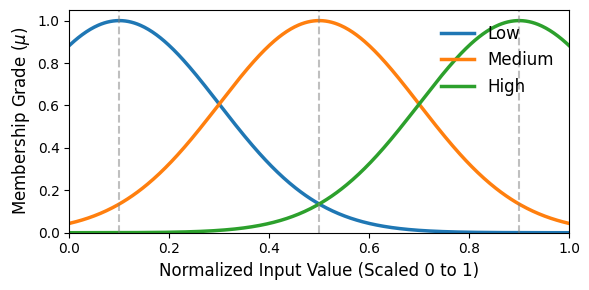

In [14]:
# Cement
cement_means = [0.1, 0.5, 0.9]     # Initial means for Low, Medium, High Age
cement_sigmas = [0.2, 0.2, 0.2]    # Initial width (standard deviation)
draw_gaussian_membership(cement_means, cement_sigmas)

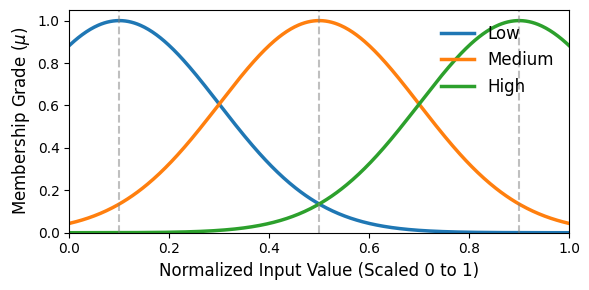

In [15]:
# Water
water_means = [0.1, 0.5, 0.9]     # Initial means for Low, Medium, High Age
water_sigmas = [0.2, 0.2, 0.2]    # Initial width (standard deviation)
draw_gaussian_membership(water_means, water_sigmas)

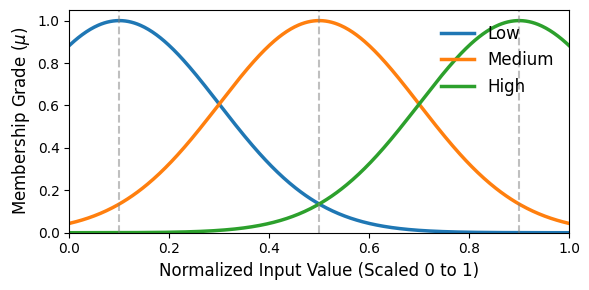

In [16]:
# Age
age_means = [0.1, 0.5, 0.9]     # Initial means for Low, Medium, High Age
age_sigmas = [0.2, 0.2, 0.2]    # Initial width (standard deviation)
draw_gaussian_membership(age_means, age_sigmas)

In [17]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

from ucimlrepo import fetch_ucirepo 

concrete_compressive_strength = fetch_ucirepo(id=165) 

In [18]:
df = pd.DataFrame(concrete_compressive_strength.data.original)
# ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Concrete compressive strength']

features = [
    'Cement', 
    'Water', 
    # 'Superplasticizer', 
    # 'Coarse Aggregate',
    'Age',
]
X = df[features].values
y = df['Concrete compressive strength'].values.reshape(-1, 1)

In [19]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features to assist PyTorch's neural network convergence
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# Convert arrays to PyTorch Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

In [20]:
class ANFIS(nn.Module):
    def __init__(self, num_inputs, num_mf=2):
        super(ANFIS, self).__init__()
        self.num_inputs = num_inputs
        self.num_mf = num_mf
        self.num_rules = num_mf ** num_inputs
        
        # 1. Premise Parameters: Gaussian MF Parameters (mean and sigma)
        # Initializing means spread across [-1, 1] and standard deviation around 1.0
        self.mf_means = nn.Parameter(torch.randn(num_inputs, num_mf))
        self.mf_sigmas = nn.Parameter(torch.ones(num_inputs, num_mf))
        
        # 2. Consequent Parameters (First-order Sugeno: y = p1*x1 + p2*x2 + ... + r)
        # Each rule requires (num_inputs + 1) coefficients
        self.consequent_params = nn.Parameter(torch.randn(self.num_rules, num_inputs + 1))
        
        # Generate grid indices to map combinations of inputs to individual rules
        # e.g., for 3 inputs with 3 MFs each -> 27 rules
        grids = torch.meshgrid([torch.arange(num_mf) for _ in range(num_inputs)], indexing='ij')
        self.rule_grid = torch.stack([g.flatten() for g in grids], dim=1) # Shape: (num_rules, num_inputs)

    def forward(self, x):
        batch_size = x.shape[0]
        
        # Layer 1: Fuzzification (Compute Gaussian Membership Values)
        # Shape: (batch_size, num_inputs, num_mf)
        x_expanded = x.unsqueeze(2).repeat(1, 1, self.num_mf)
        means = self.mf_means.unsqueeze(0).repeat(batch_size, 1, 1)
        sigmas = self.mf_sigmas.unsqueeze(0).repeat(batch_size, 1, 1)
        
        w_inputs = torch.exp(-0.5 * ((x_expanded - means) / (sigmas + 1e-8)) ** 2)
        
        # Layer 2 & 3: Rule Firing Strengths (T-norm product)
        # Pull corresponding weights for each rule combination
        w_rules = torch.zeros(batch_size, self.num_rules, device=x.device)
        for i in range(self.num_rules):
            rule_idx = self.rule_grid[i] # mapping indices for rule 'i'
            # Multiply across inputs for specific membership functions
            w_rules[:, i] = torch.prod(torch.stack([w_inputs[:, j, rule_idx[j]] for j in range(self.num_inputs)], dim=1), dim=1)
        
        # Normalize weights
        w_sum = torch.sum(w_rules, dim=1, keepdim=True) + 1e-8
        w_normalized = w_rules / w_sum # Shape: (batch_size, num_rules)
        
        # Layer 4 & 5: Consequent Evaluation and Defuzzification
        # Calculate individual rule outputs: f_i = p_0*x_0 + p_1*x_1 + ... + bias
        x_biased = torch.cat([x, torch.ones(batch_size, 1, device=x.device)], dim=1) # (batch_size, num_inputs + 1)
        
        # Shape: (batch_size, num_rules)
        rule_outputs = torch.matmul(x_biased, self.consequent_params.T)
        
        # Defuzzified output: Weighted global sum
        output = torch.sum(w_normalized * rule_outputs, dim=1, keepdim=True)
        return output

In [21]:
# Instantiate ANFIS model (4 Inputs, 2 Membership Functions per input = 16 fuzzy rules)
model = ANFIS(num_inputs=len(features), num_mf=3)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# Training Loop
epochs = 1000
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    predictions = model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    
    # Backward pass and Optimization step
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {loss.item():.4f}")

Epoch [50/1000] | Train Loss (MSE): 0.7018
Epoch [100/1000] | Train Loss (MSE): 0.4993
Epoch [150/1000] | Train Loss (MSE): 0.3894
Epoch [200/1000] | Train Loss (MSE): 0.3163
Epoch [250/1000] | Train Loss (MSE): 0.3004
Epoch [300/1000] | Train Loss (MSE): 0.2924
Epoch [350/1000] | Train Loss (MSE): 0.2858
Epoch [400/1000] | Train Loss (MSE): 0.2801
Epoch [450/1000] | Train Loss (MSE): 0.2752
Epoch [500/1000] | Train Loss (MSE): 0.2710
Epoch [550/1000] | Train Loss (MSE): 0.2673
Epoch [600/1000] | Train Loss (MSE): 0.2640
Epoch [650/1000] | Train Loss (MSE): 0.2609
Epoch [700/1000] | Train Loss (MSE): 0.2582
Epoch [750/1000] | Train Loss (MSE): 0.2556
Epoch [800/1000] | Train Loss (MSE): 0.2533
Epoch [850/1000] | Train Loss (MSE): 0.2510
Epoch [900/1000] | Train Loss (MSE): 0.2488
Epoch [950/1000] | Train Loss (MSE): 0.2467
Epoch [1000/1000] | Train Loss (MSE): 0.2447


In [25]:
# Evaluation mode
model.eval()
with torch.no_grad():
    test_preds_scaled = model(X_test_tensor).numpy()

# Invert Scaling to get back metrics in real units (MPa)
test_preds = scaler_y.inverse_transform(test_preds_scaled)

# Calculate Evaluation Metrics
mae = np.mean(np.abs(test_preds - y_test))
rmse = np.sqrt(np.mean((test_preds - y_test) ** 2))
r2 = 1 - (np.sum((y_test - test_preds) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2))

print("\nModel Evaluation")
print(f"Mean Absolute Error (MAE): {mae:.2f} MPa")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MPa")
print(f"R-squared (R²) Score: {r2:.4f}")


Model Evaluation
Mean Absolute Error (MAE): 6.60 MPa
Root Mean Squared Error (RMSE): 8.55 MPa
R-squared (R²) Score: 0.7165


In [23]:
import joblib
import torch

# 1. Save the ANFIS model weights
model_path = "anfis_concrete_model.pth"
torch.save(model.state_dict(), model_path)
print(f"ANFIS Model weights saved to {model_path}")

# 2. Save the scalers (Crucial for preprocessing new data later)
scalers = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'features': features # Storing the names of the 4 features we used
}
scalers_path = "concrete_scalers.pkl"
joblib.dump(scalers, scalers_path)
print(f"Scalers saved to {scalers_path}")

ANFIS Model weights saved to anfis_concrete_model.pth
Scalers saved to concrete_scalers.pkl
